# 4교시 | 추론 메커니즘
**환경**: Google Colab | **방법**: 이론 + 실습

---

## 학습 목표

- Temperature, Top-k, Top-p(Nucleus) 샘플링의 수식과 직관적 차이를 설명할 수 있다.
- 동일한 프롬프트에서 디코딩 전략에 따라 출력이 어떻게 달라지는지 실험으로 확인한다.
- 실제 LLM(Large Language Model) 서비스에서 권장 기본값이 무엇인지, 그 이유를 설명할 수 있다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 모델이 이미 계산한 확률 분포에서 어떤 규칙으로 다음 토큰을 고르는지 배우는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: Greedy는 가장 안전한 선택, Sampling은 더 다양한 선택이라고 구분할 수 있으면 출발점으로 충분하다.
- 헷갈려도 괜찮은 부분: Top-k, Top-p, Temperature 차이를 처음부터 완벽히 구분하지 못해도 된다. 실습 결과를 비교하면서 감을 잡아도 늦지 않다.

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| Greedy | 매번 확률 1등 토큰만 고르는 방식 |
| Temperature | 확률 분포를 더 날카롭거나 평평하게 만드는 조절값 |
| Top-k | 상위 k개 후보만 남기고 고르는 방식 |
| Top-p | 누적확률 p까지의 후보만 남기고 고르는 방식 |
| Beam Search | 여러 문장 후보를 동시에 추적하는 방식 |
| Logits | softmax 이전의 점수 |
---
  *Reasoning모델에서는 적용X

## 이론

### 왜 확률적 생성인가?

3교시에서 구현한 Greedy 생성은 매번 같은 결과를 낸다. 그러나 실제 서비스(ChatGPT, Claude 등)는 같은 질문에 매번 조금씩 다른 답변을 생성한다. 이것이 **확률 분포에서의 샘플링** 때문이다.

먼저 큰 흐름을 한 문장으로 잡으면 아래와 같다.

> 모델은 "다음 토큰 후보들의 점수"를 내고, 디코딩 전략은 그 점수들 중에서 "어떻게 하나를 고를지"를 결정한다.

즉, 추론 메커니즘은 모델이 지식을 새로 만들어내는 과정이 아니라, **이미 계산된 확률 분포를 어떤 규칙으로 읽을지 정하는 과정**이다.  
같은 모델이어도 디코딩 전략이 다르면 전혀 다른 문장 스타일이 나오는 이유가 여기에 있다.

### 한 스텝에서 실제로 무슨 일이 일어날까

학습자가 가장 헷갈리기 쉬운 부분은 "샘플링이 정확히 어디서 일어나는가"이다. 한 스텝의 흐름은 아래와 같다.

1. 현재까지의 프롬프트를 모델에 넣는다.
2. 모델이 다음 토큰에 대한 `logits`를 만든다.
3. 필요하면 Temperature, Top-k, Top-p로 후보 분포를 조정한다.
4. 조정된 분포에서 토큰 하나를 선택한다.
5. 그 토큰을 문장 뒤에 붙이고 다음 스텝으로 넘어간다.

정리하면, **모델은 logits를 만들고 디코더는 선택 규칙을 적용한다**.

### 디코딩 전략 비교

| 전략 | 핵심 아이디어 | 특징 |
|---|---|---|
| **Greedy** | 매 스텝 최고 확률 토큰 | 결정론적, 반복적, 창의성 낮음 |
| **Temperature** | 분포를 날카롭게/평탄하게 조절 | T<1: 보수적, T>1: 창의적 |
| **Top-k** | 상위 k개 토큰만 후보로 제한 | 이상한 토큰 완전 차단 |
| **Top-p (Nucleus)** | 누적확률 p 이하의 최소 집합 | 동적 후보 크기, 품질↑ |
| **Beam Search** | 상위 B개 시퀀스를 병렬 유지 | 번역 등 정확도 필요 시 유리 |

혼자 공부할 때는 아래처럼 이해하면 빠르다.

- Greedy: 항상 1등만 뽑는다.
- Temperature: 전체 분포의 "날카로움"을 조절한다.
- Top-k: 후보 수를 고정한다.
- Top-p: 후보의 "누적 확률 질량"을 기준으로 동적으로 자른다.
- Beam Search: 한 번에 여러 문장 후보를 추적한다.

### Temperature 수식

$$P'(x_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- `T → 0`: 가장 높은 확률 토큰에 모든 확률 집중 (= Greedy)
- `T = 1.0`: 원래 모델 분포 그대로
- `T > 1`: 모든 토큰의 확률이 균등해짐 → 예측 불가한 출력

```
원래 분포:   [0.60, 0.25, 0.10, 0.05]
T=0.5 적용: [0.85, 0.10, 0.03, 0.02]  ← 날카로워짐
T=2.0 적용: [0.40, 0.30, 0.20, 0.10]  ← 평탄해짐
```

직관적으로 보면 Temperature는 모델의 "성격"을 바꾸는 것이 아니라, **기존 확률 분포를 더 자신감 있게 만들지, 더 모험적으로 만들지 조절하는 손잡이**다.

- 낮은 Temperature: 안전하지만 반복적이기 쉬움
- 높은 Temperature: 다양하지만 문법 오류나 비약이 늘 수 있음

중요한 점은 Temperature가 높다고 모델이 더 똑똑해지는 것은 아니라는 것이다.  
단지 낮은 확률 후보도 선택될 가능성을 키우는 것뿐이다.

### Top-k 샘플링

상위 k개 토큰을 제외한 나머지를 확률 0으로 만든 뒤 다시 정규화한다.

- k=1: Greedy와 동일
- k=50: 실제 서비스에서 자주 사용

**단점**: 분포의 형태에 무관하게 항상 k개를 유지 → 분포가 균등하면 이상한 토큰도 포함됨

예를 들어 어떤 스텝에서는 상위 3개 토큰만 사실상 유의미할 수 있는데, `k=50`이면 덜 자연스러운 후보도 억지로 후보군에 남는다. 그래서 Top-k는 단순하고 강력하지만, 분포 모양을 세밀하게 반영하지는 못한다.

### Top-p (Nucleus) 샘플링

확률을 높은 순서대로 누적하다가 누적합이 p를 넘는 최소 집합을 후보로 삼는다.

```
확률 정렬: [0.40, 0.25, 0.15, 0.10, 0.05, ...]
p=0.9 적용: 0.40+0.25+0.15+0.10 = 0.90 → 상위 4개만 사용
```

- 분포가 뾰족하면 후보가 적고(안정적), 분포가 평탄하면 후보가 많아짐(창의적)
- **현재 가장 널리 사용되는 방식** — 대부분의 LLM 서비스 기본값

Top-p가 실전에서 선호되는 이유는, 모델이 매우 확신하는 상황에서는 후보를 자동으로 좁히고, 애매한 상황에서는 후보를 넓혀 주기 때문이다.  
즉, **문맥에 따라 유연하게 보수적이거나 창의적으로 행동할 수 있다**.

이 점이 Top-k와의 가장 큰 차이다.

- Top-k: "항상 후보 수를 k개로 맞춘다"
- Top-p: "항상 중요한 확률 질량만 남긴다"

### Beam Search는 왜 덜 자주 쓰일까

Beam Search는 여러 후보 문장을 병렬로 유지하므로 번역, 요약처럼 "정확하고 안정적인 한 문장"이 중요한 작업에는 유리할 수 있다. 하지만 자유 생성에서는 표현이 딱딱해지거나 비슷한 후보만 반복적으로 남는 경우가 많아, 대화형 LLM 기본값으로는 덜 쓰인다.

### 실전 권장 조합

```text
# ChatGPT, Claude 등 실제 서비스에서 사용하는 전형적 설정
temperature = 0.7   # 또는 0.8
top_p       = 0.9   # nucleus sampling
top_k       = 0     # top-p 사용 시 top-k는 비활성화
```



이 조합이 자주 쓰이는 이유는 아래와 같다.

- `temperature`가 너무 낮지 않아 표현 다양성이 남아 있다.
- `top_p=0.9`가 너무 희귀한 후보를 잘라 품질을 안정화한다.
- Top-k를 함께 강하게 걸지 않아 분포를 과도하게 잘라내지 않는다.

물론 정답은 작업 종류에 따라 달라진다.

- 코드 생성: 더 낮은 Temperature가 유리한 경우가 많음
- 브레인스토밍: 더 높은 Temperature가 유리할 수 있음
- 사실 기반 응답: Top-p를 낮추고 보수적으로 가는 편이 안정적임

### 이론을 읽을 때 꼭 잡아야 할 연결 고리

아래 다섯 문장을 스스로 설명할 수 있으면 이번 차시 핵심을 이해한 것이다.

1. 모델은 먼저 logits를 만들고, 디코딩 전략은 그 logits를 바탕으로 선택 규칙을 적용한다.
2. Greedy는 항상 가장 높은 확률 토큰만 선택한다.
3. Temperature는 분포의 모양을 바꾸지만 후보 순위를 크게 뒤집는 장치는 아니다.
4. Top-k는 후보 수를 고정하고, Top-p는 누적확률 기준으로 후보를 정한다.
5. 실전에서는 자연스러움과 안정성의 균형 때문에 Top-p 기반 샘플링이 자주 쓰인다.

---

## 실습

### 자주 막히는 오류

- Temperature를 높였는데 큰 차이가 안 남: 프롬프트가 너무 짧거나 후보 분포가 이미 뾰족하면 변화가 작을 수 있다.
- Greedy와 Temperature=0.3이 비슷함: 낮은 Temperature는 원래 가장 높은 확률 토큰을 더 강하게 밀어준다.
- Top-p가 직관적으로 헷갈림: 후보 개수 고정이 아니라 누적확률 기준이라는 점을 먼저 기억한다.
- 결과가 매번 달라짐: sampling 기반 설정은 실행마다 출력이 달라질 수 있다.

### 실패했을 때 체크 순서

1. 현재 디코딩 설정을 다시 읽는다: `temperature`, `top_k`, `top_p`, `do_sample` 값이 무엇인지 먼저 확인한다.
2. 비교 기준을 하나만 바꿨는지 본다: 여러 값을 동시에 바꾸면 왜 결과가 달라졌는지 해석하기 어려워진다.
3. 같은 프롬프트로 다시 실행한다: 입력을 고정한 뒤 설정 하나만 조절해 차이를 다시 본다.

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 차시의 실습은 크게 세 부분이다.

1. 같은 프롬프트에 여러 디코딩 전략을 적용해 결과 비교하기
2. Temperature가 확률 분포를 어떻게 바꾸는지 시각적으로 확인하기
3. Top-p가 후보를 어떻게 선택하는지 수치로 이해하기

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행한 뒤 출력 결과를 확인하고 다음 셀로 넘어가면 된다.

### Step 0. 실습 준비

먼저 필요한 패키지를 설치하고 기본 라이브러리를 import한다.

In [1]:
!pip install -q transformers torch matplotlib numpy

import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer



이 단계에서 확인할 점:

- 패키지 설치 오류가 없는가?
- import가 정상적으로 되는가?

### Step 1. GPT-2 모델과 토크나이저 로드

이번 실습에서는 `GPT2LMHeadModel`을 사용한다.  
이 모델은 다음 토큰 예측에 필요한 `logits`를 직접 출력할 수 있다.

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("모델 로드 완료")
print("사용 모델: gpt2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

모델 로드 완료
사용 모델: gpt2




이 단계에서 확인할 점:

- 모델과 토크나이저가 정상적으로 로드되는가?
- 이후 `generate()`와 수동 생성 실험을 할 준비가 되었는가?

### Step 2. 여러 디코딩 전략을 쉽게 비교할 함수 만들기

같은 프롬프트에 대해 설정만 바꿔 결과를 비교할 수 있도록 함수를 만든다.

In [ ]:
def generate(prompt, max_new_tokens=40, seed=42, **kwargs):
    # 실험 재현성을 위해 시드 고정
    torch.manual_seed(seed)

    # 텍스트를 모델 입력 형식으로 변환
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs,
        )

    # 사람이 읽을 수 있는 문자열로 복원
    return tokenizer.decode(out[0], skip_special_tokens=True)

이 단계에서 확인할 점:

- 이 함수는 "프롬프트를 넣으면, 지정한 디코딩 설정으로 문장을 생성해서 돌려주는 실험 도구"라고 이해하면 된다. 즉, 이후 실습에서는 코드를 매번 길게 다시 쓰지 않고 이 함수에 설정만 바꿔 넣어 결과를 비교하게 된다.
- `prompt`는 시작 문장이고, `max_new_tokens=40`은 프롬프트 뒤에 **최대 몇 개의 새 토큰을 더 붙일지** 정하는 값이다. 따라서 이 값이 크면 더 길게 생성되고, 작으면 짧게 끊긴다.
- `seed=42`는 무작위 선택이 들어가는 Sampling 실험을 다시 실행해도 비슷한 결과가 나오도록 맞춰 주는 장치다. 즉, 실험 재현성을 위해 "랜덤 출발점"을 고정한다고 이해하면 된다.
- `inputs = tokenizer(prompt, return_tensors="pt")` 부분은 사람이 읽는 문장을 모델이 계산할 수 있는 텐서 형태로 바꾸는 단계다. 앞 교시에서 본 것처럼, 모델은 문자열 자체가 아니라 토큰 ID 텐서를 입력으로 받는다.
- `model.generate(..., **kwargs)`에서 `**kwargs`는 디코딩 전략별 옵션을 나중에 바깥에서 넣기 위한 자리다. 예를 들어 `do_sample=True`, `temperature=0.8`, `top_p=0.9` 같은 값이 여기에 들어간다.
- 따라서 이 단계의 핵심은 "함수 하나를 잘 만들어 두면, 프롬프트는 그대로 두고 디코딩 옵션만 바꿔 Greedy, Temperature, Top-p 결과를 쉽게 비교할 수 있다"는 점을 이해하는 것이다.

### Step 3. 실험할 프롬프트와 전략 목록 준비

이제 동일한 프롬프트에 여러 디코딩 전략을 적용할 준비를 한다.

In [ ]:
prompt = "Once upon a time in a world full of AI,"

strategies = {
    "① Greedy": dict(do_sample=False),
    "② Temperature=0.3": dict(do_sample=True, temperature=0.3),
    "③ Temperature=1.0": dict(do_sample=True, temperature=1.0),
    "④ Temperature=1.8": dict(do_sample=True, temperature=1.8),
    "⑤ Top-k=10": dict(do_sample=True, top_k=10),
    "⑥ Top-k=100": dict(do_sample=True, top_k=100),
    "⑦ Top-p=0.9": dict(do_sample=True, top_p=0.9, top_k=0),
    "⑧ Top-p+Temp (권장)": dict(do_sample=True, top_p=0.9, temperature=0.8),
}

print(f"[프롬프트]\n{prompt}")
print(f"비교할 전략 수: {len(strategies)}")

[프롬프트]
Once upon a time in a world full of AI,
비교할 전략 수: 8


이 단계에서 확인할 점:

- `[프롬프트] Once upon a time in a world full of AI,`는 이번 실험에서 **모든 전략이 공통으로 사용할 시작 문장**을 뜻한다. 즉, 이후 결과가 달라지더라도 출발 문장은 모두 같고, 달라지는 것은 디코딩 규칙뿐이다.
- `비교할 전략 수: 8`은 우리가 같은 프롬프트에 대해 총 8가지 설정을 비교한다는 뜻이다. 다시 말해, Greedy 1개와 Temperature, Top-k, Top-p 계열 설정들을 한 번씩 같은 조건에서 시험해 보겠다는 의미다.
- 이 단계의 핵심은 아직 "어떤 전략이 더 좋다"를 판단하는 것이 아니라, **비교 실험의 조건을 먼저 고정하는 것**이다. 프롬프트가 바뀌면 출력 차이가 전략 때문인지 입력 문장 때문인지 구분하기 어려워진다.
- 따라서 여기서는 "입력은 하나로 고정하고, 선택 규칙만 여러 개 준비했다"고 이해하면 된다. 이것이 되어 있어야 다음 단계에서 나온 문장 차이를 공정하게 해석할 수 있다.
- `strategies` 딕셔너리 안의 각 항목은 "전략 이름표 + 그 전략에 해당하는 설정값 묶음"이다. 예를 들어 `① Greedy`는 `do_sample=False`, `⑦ Top-p=0.9`는 `top_p=0.9` 같은 식으로 연결된다.

### Step 4. 전략별 생성 결과 비교하기

이제 각 전략으로 실제 출력을 생성해 비교한다.  
핵심은 "모델은 같고, 선택 규칙만 다르다"는 점이다.

In [ ]:
print("\n[전략별 생성 결과 비교]")
print("=" * 65)

for name, params in strategies.items():
    result = generate(prompt, **params)

    # 프롬프트 뒤에 새로 생성된 부분만 분리해서 보기 쉽게 출력
    generated_part = result[len(prompt):]

    print(f"\n{name}")
    print(f"  {prompt}【{generated_part}】")


[전략별 생성 결과 비교]

① Greedy
  Once upon a time in a world full of AI,【 you would have to be a genius to be able to do it.

The AI is a bit of a mystery, but it's a very important part of the game. It's a very】

② Temperature=0.3
  Once upon a time in a world full of AI,【 you would have to be able to pick up a copy of the game and play it. But now it's possible to do that with a game that's not just a game.

It's】

③ Temperature=1.0
  Once upon a time in a world full of AI,【 I would've thought AI would have evolved more rapidly than it is now, but here it is again. The AI's skill sets are much different than most players think. They all employ different tools –】

④ Temperature=1.8
  Once upon a time in a world full of AI,【 I would've given them the 'right' hand: to manipulate their feelings and their thoughts...to understand them for what they were...even more than an agent of a race who believes itself to provide】

⑤ Top-k=10
  Once upon a time in a world full of AI,【 I would've thought 

이 단계에서 확인할 점:

- 각 항목은 **같은 프롬프트에 서로 다른 디코딩 규칙만 적용했을 때 나온 결과**다. 즉, 모델 자체가 바뀐 것이 아니라 "다음 토큰을 고르는 방식"만 달라졌는데도 문장 전개가 크게 달라질 수 있음을 보여 준다.
- `① Greedy`는 매번 가장 확률이 높은 토큰만 고르기 때문에, 문장이 비교적 안전한 방향으로 흐르지만 `It's a very...`처럼 반복적이거나 단조로운 패턴이 나타나기 쉽다. 즉, Greedy는 안정적이지만 표현이 뻔해질 수 있다.
- `② Temperature=0.3`은 분포를 더 날카롭게 만들어 높은 확률 후보를 더 강하게 밀어 주므로, 보통 Greedy와 꽤 비슷한 분위기의 문장이 나온다. 이번 결과도 비교적 무난하고 보수적인 흐름을 보인다는 점에 주목하면 된다.
- `③ Temperature=1.0`과 `④ Temperature=1.8`을 비교하면, Temperature가 높아질수록 문장이 더 예측하기 어려운 방향으로 전개될 수 있음을 볼 수 있다. 특히 `1.8`에서는 표현이 더 길고 비약적이며, 문맥이 과감하게 튀는 느낌이 강해질 수 있다. 이것이 높은 Temperature의 전형적인 특징이다.
- `⑤ Top-k=10`과 `⑥ Top-k=100`을 비교하면, 후보 수를 적게 제한할수록 더 보수적인 문장이 나오고, 후보 수를 넓게 열어 둘수록 더 다양한 표현이 섞일 여지가 생긴다고 이해하면 된다. 즉, Top-k는 "후보 풀의 크기"를 조절하는 방식이다.
- `⑦ Top-p=0.9`는 누적확률 기준으로 후보를 남기기 때문에, 어떤 순간에는 꽤 넓은 후보가 살아남아 `materialistic fiefdoms, theories, conversations...`처럼 예상보다 더 자유롭고 독특한 전개가 나올 수 있다. 이것은 오류라기보다 Top-p가 현재 분포 모양에 따라 유연하게 후보 수를 정하기 때문이다.
- `⑧ Top-p+Temp (권장)`은 너무 보수적이지도, 너무 튀지도 않는 중간 지점을 보여 주는 예시로 읽으면 된다. 이번 출력에서도 Greedy보다 덜 단조롭고, 높은 Temperature보다 덜 불안정하게 이어지므로, 왜 실전에서 이런 조합이 자주 쓰이는지 감을 잡을 수 있다.
- 따라서 이 단계의 핵심은 "같은 프롬프트라도 디코딩 전략이 달라지면 문장 스타일, 다양성, 안정성이 함께 달라진다"는 점을 실제 출력으로 확인하는 것이다.

### Step 5. Temperature가 분포를 어떻게 바꾸는지 시각화하기

이번 단계에서는 실제 모델 출력 대신 간단한 예시 logits를 사용해 Temperature의 효과를 직관적으로 본다.  
이렇게 하면 "왜 Temperature가 확률을 날카롭게 또는 평탄하게 만드는지"를 수치와 그래프로 이해하기 쉽다.


[Temperature별 분포 변화 시각화]


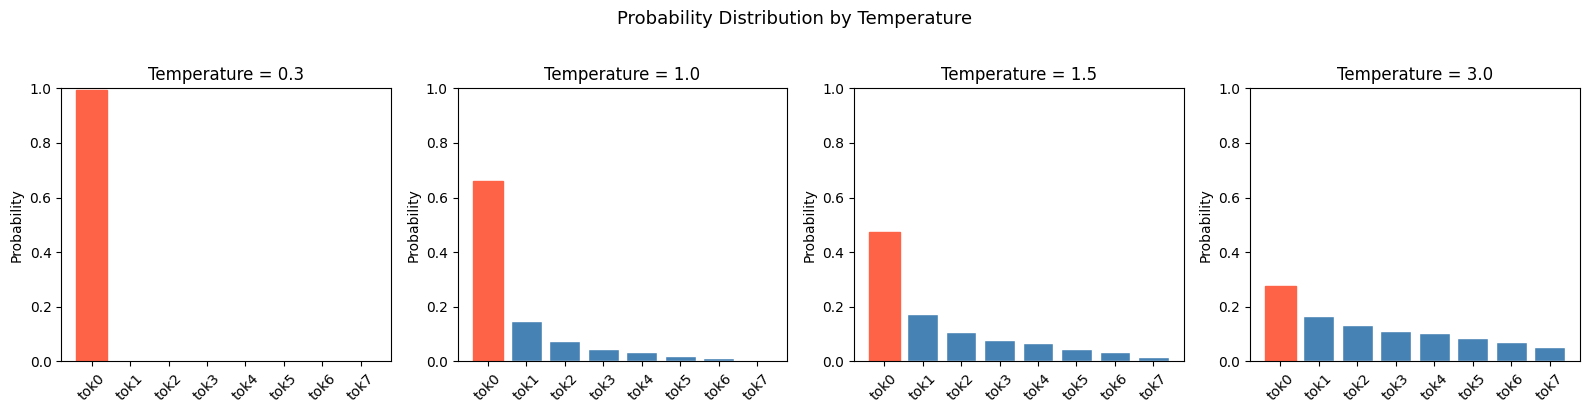

In [ ]:
print("\n[Temperature별 분포 변화 시각화]")

# 예시 logits: 가장 높은 후보부터 낮은 후보까지 점수 설정
logits = np.array([3.0, 1.5, 0.8, 0.3, 0.1, -0.5, -1.0, -2.0])
tokens_label = [f"tok{i}" for i in range(len(logits))]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, temperature in zip(axes, [0.3, 1.0, 1.5, 3.0]):
    exp_logits = np.exp(logits / temperature)
    probs = exp_logits / exp_logits.sum()

    bars = ax.bar(tokens_label, probs, color="steelblue", edgecolor="white")
    ax.set_title(f"Temperature = {temperature}", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Probability")
    ax.tick_params(axis="x", rotation=45)

    # 가장 높은 확률 막대를 눈에 띄게 표시
    bars[probs.argmax()].set_color("tomato")

plt.suptitle("Probability Distribution by Temperature", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

이 단계에서 확인할 점:

- 그래프 하나는 "같은 logits에 Temperature만 바꿨을 때 확률 분포가 어떻게 달라지는가"를 보여 준다. 즉, 토큰 종류(`tok0`, `tok1`...)는 그대로이고, **막대 높이만 Temperature에 따라 달라진다**는 점이 핵심이다.
- 결과에서 `Temperature = 0.3`을 보면 `tok0` 막대가 거의 1.0에 가깝고, 나머지는 거의 0에 붙어 있다. 이것은 모델이 사실상 "1등 후보 하나만 거의 확실하게 선택하는 상태"에 가까워졌다는 뜻이다. 그래서 낮은 Temperature는 Greedy와 비슷하게 매우 보수적인 선택을 만들기 쉽다.
- `Temperature = 1.0`은 원래 분포에 가까운 상태라고 읽으면 된다. 여전히 `tok0`가 가장 높지만, `tok1`, `tok2` 같은 다른 후보들도 어느 정도 확률을 유지하고 있어 "1등 후보가 우세하지만 다른 선택지도 남아 있는 상태"라고 볼 수 있다.
- `Temperature = 1.5`와 `Temperature = 3.0`으로 갈수록 가장 높은 막대와 다른 막대의 차이가 점점 줄어든다. 즉, 1등 후보만 압도적으로 강한 것이 아니라 여러 후보가 함께 살아나며 분포가 더 평평해진다.
- 특히 `Temperature = 3.0`에서는 `tok0`가 여전히 가장 높지만, 다른 토큰 막대들도 꽤 눈에 띄게 올라와 있다. 이것은 원래는 낮은 확률이던 후보들도 선택될 가능성이 커졌다는 뜻이다. 그래서 Temperature가 높아질수록 더 다양한 출력이 나오지만, 동시에 더 불안정하거나 어색한 토큰이 섞일 가능성도 커진다.
- 따라서 이 단계의 핵심은 "Temperature는 후보 순서를 새로 만드는 장치"라기보다, **원래 있던 확률 차이를 더 벌리거나(낮은 Temperature), 더 줄이는(높은 Temperature) 조절 장치**라는 점을 그래프로 읽어내는 것이다.

### Step 6. Top-p가 후보를 어떻게 고르는지 수치로 보기

이번 단계에서는 Top-p가 "상위 몇 개를 무조건 고르는 방식"이 아니라, 누적확률 기준으로 후보를 정한다는 점을 수치로 확인한다.

In [ ]:
print("\n[Top-p=0.9 후보 선택 과정]")

probs_example = np.array([0.35, 0.22, 0.15, 0.10, 0.08, 0.05, 0.03, 0.02])

# 확률이 높은 순서대로 정렬
sorted_idx = np.argsort(probs_example)[::-1]
sorted_probs = probs_example[sorted_idx]
cumsum = np.cumsum(sorted_probs)

print(f"{'순위':<5} {'토큰':<10} {'확률':<8} {'누적확률':<10} {'포함여부'}")
print("-" * 45)

for rank, (idx, prob, cum_prob) in enumerate(zip(sorted_idx, sorted_probs, cumsum), 1):
    # 누적확률이 0.9를 넘기기 전까지의 최소 집합을 선택한다고 이해하면 된다.
    included = "✅" if cum_prob <= 0.9 + sorted_probs[0] * 0.001 else "❌"
    print(f"  {rank:<4} tok{idx:<6} {prob:.3f}   {cum_prob:.3f}      {included}")


[Top-p=0.9 후보 선택 과정]
순위    토큰         확률       누적확률       포함여부
---------------------------------------------
  1    tok0      0.350   0.350      ✅
  2    tok1      0.220   0.570      ✅
  3    tok2      0.150   0.720      ✅
  4    tok3      0.100   0.820      ✅
  5    tok4      0.080   0.900      ✅
  6    tok5      0.050   0.950      ❌
  7    tok6      0.030   0.980      ❌
  8    tok7      0.020   1.000      ❌


이 단계에서 확인할 점:

- 이 표는 "확률이 높은 순서대로 토큰을 하나씩 더해 가면서, 누적확률이 0.9에 도달할 때까지 어디까지 후보로 남기는가"를 보여 준다. 즉, Top-p는 순위만 보는 것이 아니라 **확률을 누적해서 후보 집합을 정하는 방식**이다.
- 현재 결과에서는 `tok0`부터 `tok4`까지 더하면 `0.35 + 0.22 + 0.15 + 0.10 + 0.08 = 0.90`이 된다. 그래서 `tok4`까지는 `✅`로 포함되고, 그다음 `tok5`부터는 이미 누적확률 0.9를 넘겼기 때문에 `❌`로 제외된다.
- 중요한 점은 Top-p=0.9가 "상위 5개를 고른다"는 뜻이 아니라는 것이다. 이번 예시에서는 우연히 5개가 남았지만, 다른 분포에서는 3개만 남을 수도 있고 7개가 남을 수도 있다. 즉, **남는 후보 수는 확률 분포 모양에 따라 매번 달라진다.**
- `포함여부`가 `✅`인 토큰들만이 실제 sampling 대상이 된다. 따라서 Top-p는 확률이 너무 낮은 꼬리 후보들을 잘라 내어, 이상하고 희귀한 토큰이 선택될 가능성을 줄이는 역할을 한다.
- 이것이 Top-k와의 핵심 차이다. Top-k는 예를 들어 무조건 상위 5개처럼 `개수`를 먼저 정하지만, Top-p는 `중요한 확률 질량을 어디까지 포함할지`를 먼저 정한다. 그래서 모델이 확신하는 상황에서는 후보 수가 적어지고, 애매한 상황에서는 후보 수가 더 많아질 수 있다.

### 실습을 마친 뒤 정리

위 실습이 끝나면 아래 내용을 말로 설명할 수 있어야 한다.

1. 같은 모델이라도 디코딩 전략이 다르면 출력 결과가 달라진다.
2. Greedy는 가장 안정적이지만 반복적일 수 있다.
3. Temperature는 확률 분포의 날카로움을 조절한다.
4. Top-k는 후보 수를 고정하고, Top-p는 누적확률 기준으로 후보를 정한다.
5. 실전에서는 Top-p와 적당한 Temperature 조합이 자주 쓰인다.

**관찰 과제**

1. Temperature=0.3과 Greedy의 출력이 얼마나 비슷한지 확인
2. Temperature=1.8에서 문법적으로 이상한 토큰이 등장하는지 관찰
3. Top-p=0.9(권장 조합)이 가장 자연스러운 이유를 수치로 설명해보기

---

## 핵심 개념 정리

```
Greedy      → 항상 같은 결과, 반복적 표현
Temperature → 전체 분포 조절, 날카롭게 or 평탄하게
Top-k       → 하위 토큰 완전 차단, k 고정
Top-p       → 분포에 따라 동적으로 후보 크기 조절 ← 실전 권장
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 이론 이해가 잘 된 것이다.

1. `logits`와 실제 샘플링 확률은 어떻게 다른가?
2. Temperature를 높이면 왜 더 다양한 출력이 나오는가?
3. Top-k와 Top-p 중 어떤 방식이 문맥에 더 유연하게 반응하는가?
4. Greedy가 항상 가장 자연스러운 결과를 주지 않는 이유는 무엇인가?
5. 코드 생성과 창의적 글쓰기에서 권장 디코딩 설정이 왜 달라질 수 있는가?

---

## 다음 교시 예고

**5교시**: 긴 시퀀스를 생성할 때 매번 전체를 재계산하면 얼마나 느려지는지, KV Cache가 이를 어떻게 해결하는지 벤치마크로 직접 측정한다.

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답을 그대로 외우기보다, **실행 결과를 보고 왜 그런 차이가 나왔는지 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**1. Temperature=0.3과 Greedy의 출력이 얼마나 비슷한지 확인**

보통 Temperature=0.3은 분포를 매우 날카롭게 만들기 때문에, Greedy와 상당히 비슷한 결과가 나올 가능성이 높다. 즉, 가장 높은 확률 토큰이 거의 항상 선택되기 쉬운 상태가 된다. 완전히 동일하지는 않을 수 있지만, 전체적으로 더 보수적이고 안정적인 생성이 나타나는 것이 일반적이다.

**2. Temperature=1.8에서 문법적으로 이상한 토큰이 등장하는지 관찰**

Temperature가 높아지면 낮은 확률 후보도 선택될 가능성이 커진다. 그래서 문맥상 덜 자연스러운 단어, 문법적으로 어색한 연결, 의미적으로 튀는 표현이 등장할 수 있다. 이 실험을 통해 Temperature를 높인다는 것이 "더 창의적"이 되는 것과 동시에 "더 불안정해질 수 있음"을 함께 의미한다는 점을 이해할 수 있다.

**3. Top-p=0.9(권장 조합)이 가장 자연스러운 이유를 수치로 설명해보기**

Top-p=0.9는 누적확률 90%를 차지하는 핵심 후보들만 남기고, 확률이 너무 낮은 후보는 잘라낸다. 그래서 의미 있는 선택지는 유지하면서도 지나치게 희귀하고 부자연스러운 토큰은 배제할 수 있다. 즉, 자연스러움과 다양성 사이에서 균형이 잘 맞기 때문에 실전에서 자주 쓰인다.

### 혼자 점검하기 모범 답안

**1. `logits`와 실제 샘플링 확률은 어떻게 다른가?**

`logits`는 모델이 각 토큰 후보에 대해 계산한 원시 점수이고, 아직 확률이 아니다. 여기에 softmax를 적용하면 각 토큰이 선택될 상대적 가능성을 나타내는 확률 분포가 된다. 즉, logits는 "점수", probabilities는 "정규화된 선택 확률"이다.

**2. Temperature를 높이면 왜 더 다양한 출력이 나오는가?**

Temperature를 높이면 상위 후보와 하위 후보의 확률 차이가 줄어들어 분포가 평탄해진다. 그러면 원래는 잘 선택되지 않던 낮은 확률 토큰도 뽑힐 가능성이 높아진다. 이 때문에 더 다양한 표현이 나오지만, 동시에 더 불안정하거나 어색한 표현도 늘 수 있다.

**3. Top-k와 Top-p 중 어떤 방식이 문맥에 더 유연하게 반응하는가?**

Top-p가 더 유연하다. Top-k는 항상 후보 수를 k개로 고정하지만, Top-p는 현재 분포의 모양에 따라 필요한 후보 수를 동적으로 바꾼다. 따라서 모델이 확신하는 상황에서는 후보를 좁히고, 애매한 상황에서는 후보를 넓히는 식으로 더 자연스럽게 반응할 수 있다.

**4. Greedy가 항상 가장 자연스러운 결과를 주지 않는 이유는 무엇인가?**

Greedy는 매 스텝에서 항상 1등 토큰만 선택하므로, 지역적으로 가장 안전한 선택만 반복하게 된다. 그 결과 문장이 지나치게 단조롭거나 반복적으로 흐를 수 있다. 즉, 각 순간의 최선 선택이 항상 전체 문장의 가장 자연스러운 흐름을 보장하지는 않는다.

**5. 코드 생성과 창의적 글쓰기에서 권장 디코딩 설정이 왜 달라질 수 있는가?**

코드 생성은 정확성과 일관성이 중요하므로 더 낮은 Temperature와 보수적인 설정이 유리한 경우가 많다. 반면 창의적 글쓰기는 다양한 표현과 예측 불가능성이 더 중요하므로, 상대적으로 높은 Temperature나 Sampling 기반 설정이 더 적합할 수 있다. 즉, 디코딩 전략은 모델 자체보다도 작업의 목표에 맞게 선택해야 한다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 실습 결과를 보고 스스로 답을 말해 본다.
2. 그다음 모범 답안과 비교한다.
3. 표현이 조금 달라도 핵심 개념이 맞으면 이해한 것으로 본다.
4. 설명이 막히는 질문은 다시 그래프와 생성 결과를 확인한다.